# Twitter (X) Sentiment Analysis Project
This notebook demonstrates a full pipeline for sentiment analysis on a Twitter dataset, including loading, preprocessing, balancing, model training, and evaluation.
#### Student : Abdallah Oubella
#### Supervisor : Pr.Baqach Adil

### 📦 1. Import Libraries
We import the necessary libraries for data manipulation, visualization, preprocessing, model training, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud, STOPWORDS

**Dataset:**  
All models were evaluated on a curated subset (900,015 samples) of the [T4SA Dataset](https://www.kaggle.com/datasets/sandeepkumarkushwaha/t4sa-dataset), containing balanced sentiment classes.
<br>We have upload the dataset to our Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 📥 2. Load and Explore the Dataset
We load the dataset, examine the structure, and check for imbalances.

In [4]:
df = pd.read_csv('/content/drive/MyDrive/dataset/dataset.csv')
df.head()

,text,sentiment
0,My little pumpkin!🎃😊 https://t.co/KF4wpbYYX0,0
1,DBZ Diamond Bolero EX-TP Electric Guitar Singl...,0
2,"Come join me, or you'll be left behind #BIGOLI...",0
3,Views the other night. Mufasa spoke with me ht...,0
4,MK 1:1 Really cow leather fashion bagsanyone l...,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900015 entries, 0 to 900014
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   text       900015 non-null  object
 1   sentiment  900015 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 13.7+ MB


Text(0, 0.5, 'Fréquence')

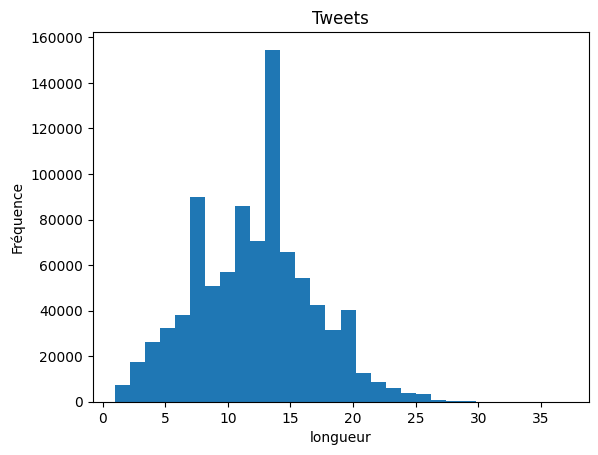

In [7]:
length_tweet = [len(s.split()) for s in df['text']]

plt.hist(length_tweet,bins=30)
plt.title('Tweets')
plt.xlabel('longueur')
plt.ylabel('Fréquence')

### 🗄️ 3. Data Preprocessing and Cleaning
We perform various data cleaning and preprocessing steps to prepare the text data for model training.

In [ ]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('omw-1.4')
import contractions
from nltk.corpus import stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
negation_words = {'no', 'not', 'nor', 'never', "n't"}
custom_stopwords = stop_words - negation_words
def preprocess_text(text):
    text = contractions.fix(text)

    text = text.lower()

    text = re.sub(r'http\S+|www\.\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = [word for word in text.split() if word not in custom_stopwords]
    lemmatized = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(lemmatized)

df['tweet'] = df['text'].apply(preprocess_text)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


### 📊 4. Data Balancing (Optional)
If the dataset is imbalanced, we can use techniques like undersampling or oversampling to balance the classes. This step is commented out as it depends on the dataset's characteristics.

<BarContainer object of 3 artists>

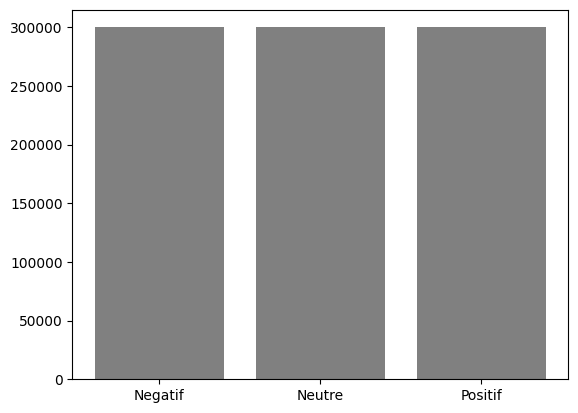

In [ ]:
a = df['sentiment'].replace({0:'Negatif', 1:'Neutre', 2:'Positif'}).value_counts()
plt.bar(a.keys(),a.values,color='gray')

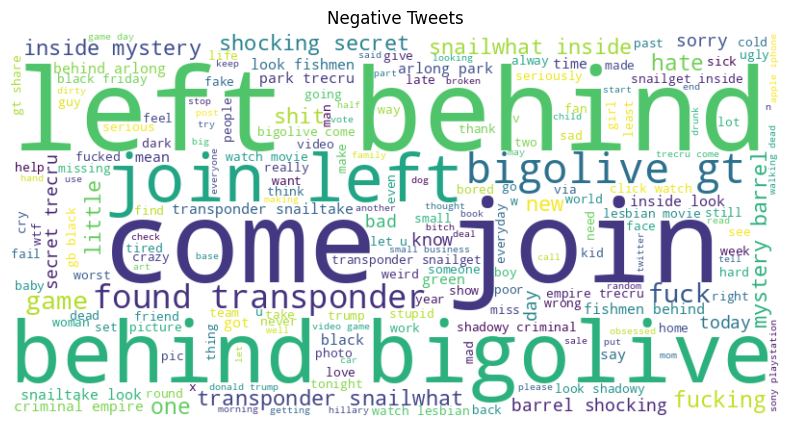

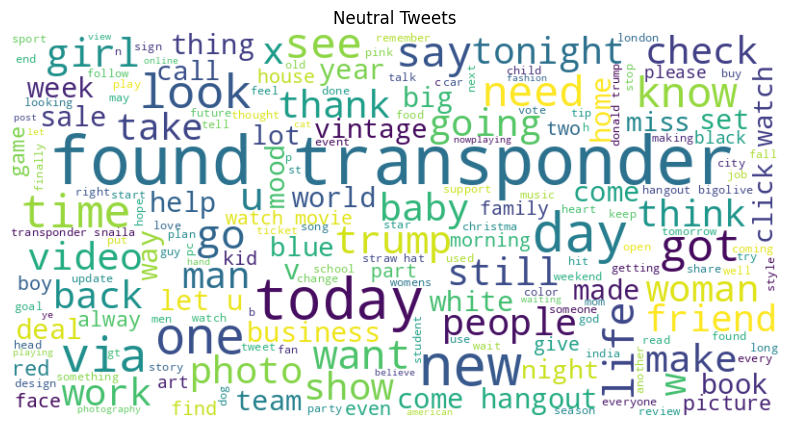

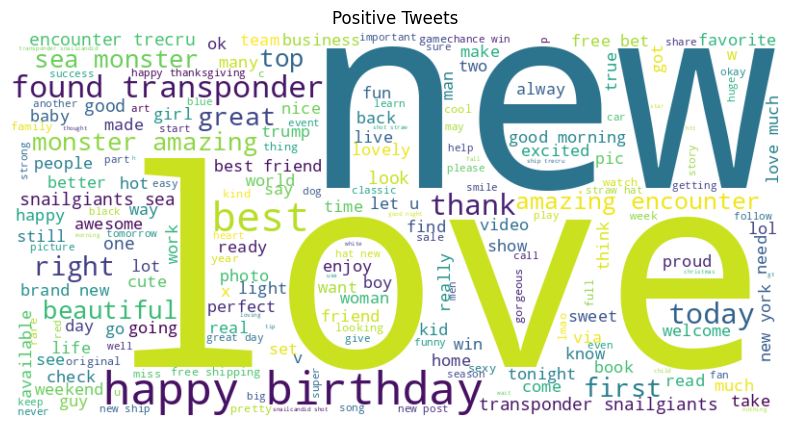

In [11]:
neg = df[df['sentiment'] == 0]
neu = df[df['sentiment'] == 1]
pos = df[df['sentiment'] == 2]

def plot_wordcloud(data, title):
    ignored_words = {'rt','amp','nan'}
    text = ' '.join(data['tweet'].astype(str).apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in ignored_words])))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()


plot_wordcloud(neg, 'Negative Tweets')
plot_wordcloud(neu, 'Neutral Tweets')
plot_wordcloud(pos, 'Positive Tweets')


### 🔪 5. Splitting Data and TF-IDF Vectorization
We split the data into training and testing sets and apply TF-IDF vectorization to convert the text data into numerical features.

In [13]:
X = df['tweet']
y = df['sentiment']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000,ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

We chose max_features=10000 because it achieved the highest accuracy.

In [ ]:
print("X_train_array shape:", X_train_tfidf.shape)
print("y_train shape:", y_train.shape)


X_train_array shape: (780321, 5000)
y_train shape: (780321,)


### 🧠 6. Test Models
We train and evaluate different machine learning models for sentiment classification.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_lr = LogisticRegression(max_iter=1000,random_state=42)
model_lr.fit(X_train_tfidf, y_train)
y_pred_lr = model_lr.predict(X_test_tfidf)
print('               Logistic Regression : ')
print("\nClassification Report:\n",classification_report(y_test, y_pred_lr))

               Logistic Regression : 

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92     60001
           1       0.87      0.92      0.89     60001
           2       0.94      0.92      0.93     60001

    accuracy                           0.91    180003
   macro avg       0.91      0.91      0.91    180003
weighted avg       0.91      0.91      0.91    180003



In [ ]:
from sklearn.metrics import classification_report
import xgboost as xgb

xgb_classifier = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)
xgb_classifier.fit(X_train_tfidf, y_train)

y_pred_xgb = xgb_classifier.predict(X_test_tfidf)
print('               XGBClassifier : ')
print("\nClassification Report:\n",classification_report(y_test, y_pred_xgb))

               XGBClassifier : 

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.80      0.86     60001
           1       0.74      0.93      0.83     60001
           2       0.93      0.83      0.88     60001

    accuracy                           0.85    180003
   macro avg       0.87      0.85      0.85    180003
weighted avg       0.87      0.85      0.85    180003



In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=5)
model_rf.fit(X_train_tfidf, y_train)

y_pred_rf = model_rf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_rf))

print('              Random Forest with 5 estimators : ')
print("\nClassification Report:\n",classification_report(y_test, y_pred_rf))

              Random Forest with 5 estimators : 

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92     60001
           1       0.87      0.91      0.89     60001
           2       0.93      0.91      0.92     60001

    accuracy                           0.91    180003
   macro avg       0.91      0.91      0.91    180003
weighted avg       0.91      0.91      0.91    180003



In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

nb_classifier = MultinomialNB()

nb_classifier.fit(X_train_tfidf, y_train)

y_pred_nb = nb_classifier.predict(X_test_tfidf)

print('              Naive Bayes : ')
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

              Naive Bayes : 

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.77      0.81     60001
           1       0.70      0.80      0.75     60001
           2       0.86      0.83      0.85     60001

    accuracy                           0.80    180003
   macro avg       0.81      0.80      0.80    180003
weighted avg       0.81      0.80      0.80    180003



In [ ]:
from sklearn.metrics import classification_report
from sklearn.svm import SVC

svm_classifier = SVC(kernel='linear')


svm_classifier.fit(X_train_tfidf, y_train)


y_pred_svm = svm_classifier.predict(X_test_tfidf)
print('              SVM : ')
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

              SVM : 

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.91      6000
           1       0.85      0.91      0.88      6000
           2       0.93      0.91      0.92      6000

    accuracy                           0.90     18000
   macro avg       0.90      0.90      0.90     18000
weighted avg       0.90      0.90      0.90     18000




## Model Comparison

Here's a comparison of the evaluated models based on their performance metrics on the test set.

| Model                     | Precision (0) | Recall (0) | F1-Score (0) | Precision (1) | Recall (1) | F1-Score (1) | Precision (2) | Recall (2) | F1-Score (2) | Accuracy |
|---------------------------|---------------|------------|--------------|---------------|------------|--------------|---------------|------------|--------------|----------|
| Logistic Regression       | 0.94          | 0.90       | 0.92         | 0.87          | 0.92       | 0.89         | 0.94          | 0.92       | 0.93         | 0.91     |
| Random Forest (5 est.)    | 0.93          | 0.90       | 0.92         | 0.87          | 0.91       | 0.89         | 0.93          | 0.91       | 0.92         | 0.91     |
| SVM                       | 0.93          | 0.88       | 0.91         | 0.85          | 0.91       | 0.88         | 0.93          | 0.91       | 0.92         | 0.90     |
| XGBClassifier             | 0.94          | 0.80       | 0.86         | 0.74          | 0.93       | 0.83         | 0.93          | 0.83       | 0.88         | 0.85     |
| Naive Bayes               | 0.86          | 0.77       | 0.81         | 0.70          | 0.80       | 0.75         | 0.86          | 0.83       | 0.85         | 0.80     |


Analysis:

Logistic Regression and Random Forest (with 5 estimators) performed best overall, showing the highest accuracy (0.91) and balanced precision and recall across all classes.

SVM provided strong performance as well, with accuracy slightly lower (0.90) but still maintaining good balance across metrics.

XGBClassifier showed higher precision for class 0 (0.94) but had lower recall for this class (0.80), resulting in a lower F1-score (0.86) compared to other models.

Naive Bayes had the lowest performance among these models, particularly in precision for class 1 (0.70) and recall for class 0 (0.77).

Based on these results, Logistic Regression or Random Forest would be the preferred models for this classification task, offering the best balance of accuracy and performance across all classes. The SVM also performs well and could be considered. The XGBClassifier and Naive Bayes might benefit from hyperparameter tuning to improve their performance.

**Note:** SVM was evaluated on a smaller test set (6,000 samples vs 60,001 for other models) due to its computationally expensive training requirements. This may affect direct comparability of accuracy metrics.

### 📈 7. Visualize Tweet Length Distribution
We visualize the distribution of tweet lengths to understand the typical length of tweets in the dataset.

Text(0, 0.5, 'Fréquence')

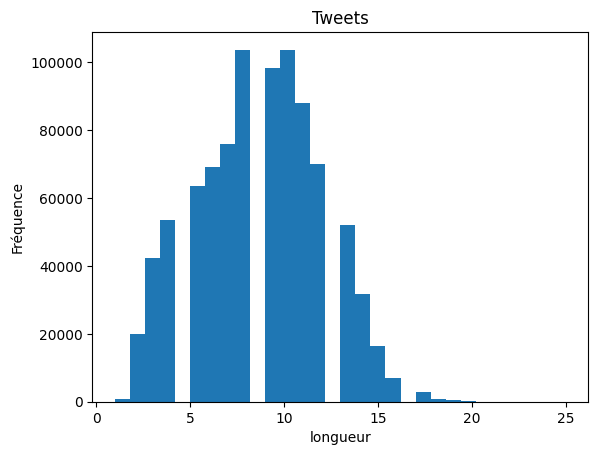

In [16]:
length_tweet = [len(s.split()) for s in df['tweet']]

plt.hist(length_tweet,bins=30)
plt.title('Tweets')
plt.xlabel('longueur')
plt.ylabel('Fréquence')

Based on the histogram visualization of tweet lengths, we are setting `maxlen` to 15.

### 🌐 8. Bidirectional LSTM and RNN Models

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf


X = df['tweet']
y = df['sentiment']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

max_len = 15
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='post', truncating='post')


y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.int32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.int32)

embedding_dim = 128
lstm_units = 64
num_classes = len(y.unique())

model_lstm = Sequential([
    Embedding(input_dim=10000, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(lstm_units, return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])


model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()


callbacks_lstm = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        mode='max'
    ),
    ModelCheckpoint(
        'best_bi_lstm_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]



history_lstm = model_lstm.fit(
    X_train_padded,
    y_train_tf,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_padded, y_test_tf),
    verbose=1,
    callbacks=callbacks_lstm
)

loss_lstm, accuracy_lstm = model_lstm.evaluate(X_test_padded, y_test_tf)
print(f"Test Loss (Bidirectional LSTM): {loss_lstm:.4f}")
print(f"Test Accuracy (Bidirectional LSTM): {accuracy_lstm:.4f}")

y_pred_probs_lstm = model_lstm.predict(X_test_padded)
y_pred_classes_lstm = np.argmax(y_pred_probs_lstm, axis=1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 317s 14ms/step - accuracy: 0.8864 - loss: 0.3553 - val_accuracy: 0.9264 - val_loss: 0.2490
Epoch 2/20
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 303s 13ms/step - accuracy: 0.9298 - loss: 0.2424 - val_accuracy: 0.9292 - val_loss: 0.2433
Epoch 3/20
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 333s 14ms/step - accuracy: 0.9356 - loss: 0.2171 - val_accuracy: 0.9301 - val_loss: 0.2415
Epoch 4/20
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 318s 14ms/step - accuracy: 0.9412 - loss: 0.1958 - val_accuracy: 0.9300 - val_loss: 0.2486
Epoch 5/20
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 323s 14ms/step - accuracy: 0.9463 - loss: 0.1770 - val_accuracy: 0.9263 - val_loss: 0.2647
Epoch 6/20
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 324s 14ms/step - accuracy: 0.9518 - loss: 0.1573 - val_accuracy: 0.9267 - val_loss: 0.2797
Epoch 7/20
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 322s 14ms/step - accuracy: 0.9567 - loss: 0.1409 - val_accuracy: 0.9198 - val_loss: 0.2978
Epoch 8/20
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 310s 13ms/s

NameError: name 'classification_report' is not defined


Classification Report (Bidirectional LSTM):
               precision    recall  f1-score   support

           0       0.96      0.91      0.94     60001
           1       0.88      0.95      0.91     60001
           2       0.95      0.93      0.94     60001

    accuracy                           0.93    180003
   macro avg       0.93      0.93      0.93    180003
weighted avg       0.93      0.93      0.93    180003


Confusion Matrix (Bidirectional LSTM):
 [[54864  4150   987]
 [ 1612 56709  1680]
 [  518  3635 55848]]


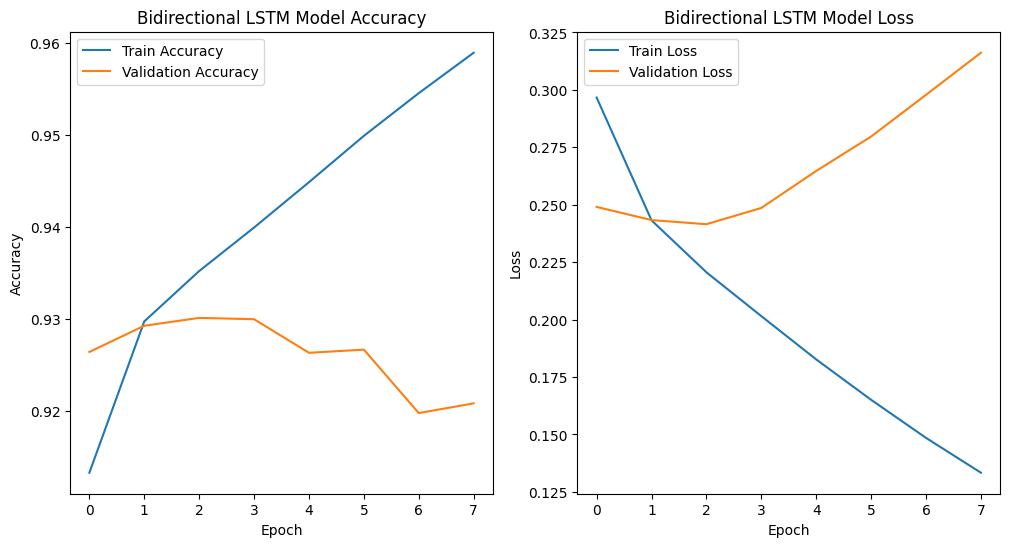

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report (Bidirectional LSTM):\n", classification_report(y_test, y_pred_classes_lstm))
print("\nConfusion Matrix (Bidirectional LSTM):\n", confusion_matrix(y_test, y_pred_classes_lstm))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('Bidirectional LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('Bidirectional LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
model_lstm.build(input_shape=(None,100))
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,161,803 (15.88 MB)

 Trainable params: 1,387,267 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,774,536 (10.58 MB)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 115s 5ms/step - accuracy: 0.8588 - loss: 0.4208 - val_accuracy: 0.9175 - val_loss: 0.2915
Epoch 2/30
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 135s 5ms/step - accuracy: 0.9192 - loss: 0.2910 - val_accuracy: 0.9182 - val_loss: 0.2793
Epoch 3/30
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 96s 4ms/step - accuracy: 0.9243 - loss: 0.2692 - val_accuracy: 0.9197 - val_loss: 0.2754
Epoch 4/30
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 147s 5ms/step - accuracy: 0.9263 - loss: 0.2590 - val_accuracy: 0.9162 - val_loss: 0.2812
Epoch 5/30
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 135s 4ms/step - accuracy: 0.9287 - loss: 0.2496 - val_accuracy: 0.9172 - val_loss: 0.2785
Epoch 6/30
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 101s 4ms/step - accuracy: 0.9311 - loss: 0.2396 - val_accuracy: 0.9178 - val_loss: 0.2830
Epoch 7/30
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 135s 4ms/step - accuracy: 0.9322 - loss: 0.2349 - val_accuracy: 0.9183 - val_loss: 0.2851
Epoch 8/30
22501/22501 ━━━━━━━━━━━━━━━━━━━━ 101s 4ms/step - acc

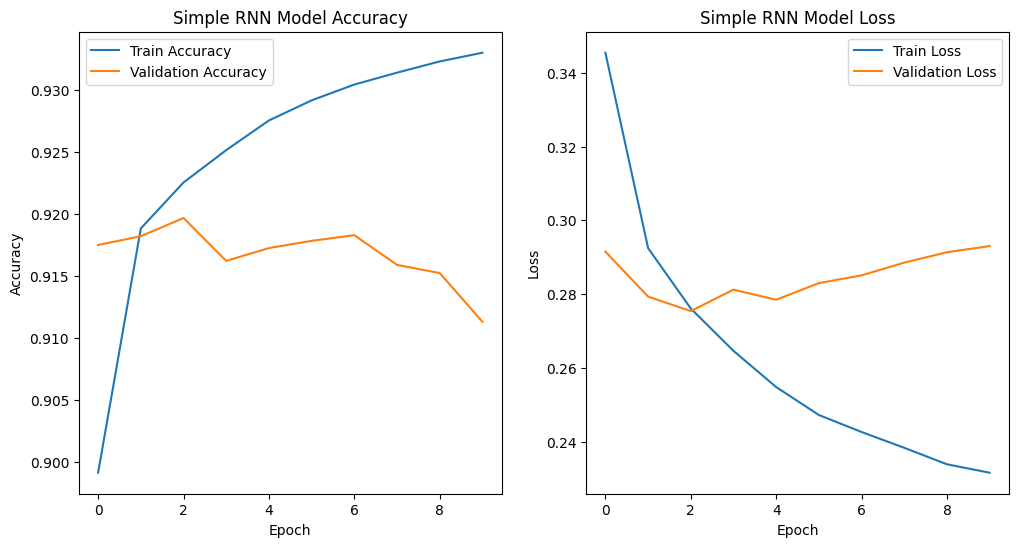

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

max_len = 15
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='post', truncating='post')


y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.int32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.int32)


vocab_size = 10000
embedding_dim = 64
rnn_units = 32
num_classes = len(y.unique())

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    SimpleRNN(rnn_units, return_sequences=False),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])


model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()


callbacks_rnn = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        mode='max'
    ),
    ModelCheckpoint(
        'best_rnn_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]


history_rnn = model_rnn.fit(
    X_train_padded,
    y_train_tf,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_padded, y_test_tf),
    verbose=1,
    callbacks=callbacks_rnn
)


loss_rnn, accuracy_rnn = model_rnn.evaluate(X_test_padded, y_test_tf)
print(f"\nTest Loss (Simple RNN): {loss_rnn:.4f}")
print(f"Test Accuracy (Simple RNN): {accuracy_rnn:.4f}")


y_pred_probs_rnn = model_rnn.predict(X_test_padded)
y_pred_classes_rnn = np.argmax(y_pred_probs_rnn, axis=1)


print("\nClassification Report (Simple RNN):\n", classification_report(y_test, y_pred_classes_rnn))
print("\nConfusion Matrix (Simple RNN):\n", confusion_matrix(y_test, y_pred_classes_rnn))


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Simple RNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('Simple RNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
model_rnn.build(input_shape=(None,15))
model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 15, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,932,779 (7.37 MB)

 Trainable params: 644,259 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,520 (4.92 MB)

# Neural Network Model Comparison

| Model               | Class 0 Precision | Class 0 Recall | Class 0 F1 | Class 1 Precision | Class 1 Recall | Class 1 F1 | Class 2 Precision | Class 2 Recall | Class 2 F1 | Accuracy |
|---------------------|------------------|----------------|------------|------------------|----------------|------------|------------------|----------------|------------|----------|
| Bidirectional LSTM  | 0.96             | 0.91           | 0.94       | 0.88             | 0.95           | 0.91       | 0.95             | 0.93           | 0.94       | 0.93     |
| Simple RNN          | 0.96             | 0.90           | 0.93       | 0.86             | 0.93           | 0.90       | 0.95             | 0.92           | 0.93       | 0.92     |

**Key Differences:**
- → Bidirectional LSTM shows +0.01 better recall on Class 0 (0.91 vs 0.90)
- → Significant +0.02 improvement in Class 1 recall (0.95 vs 0.93)
- → Consistently higher F1 scores across all classes
- → Overall accuracy advantage of +0.01 (0.93 vs 0.92)

**Recommendation:**  
The Bidirectional LSTM provides better balanced performance, especially for Class 1 predictions, making it the preferred choice despite likely higher computational requirements.

### 🤖 9. DistilBERT Model for Tokenization and Embedding

In [ ]:
def preprocess_text_bert(text):
    text = contractions.fix(text)

    text = text.lower()

    text = re.sub(r'http\S+|www\.\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return ' '.join(text)

df['tweet'] = df['text'].apply(preprocess_text)

In [ ]:
import pandas as pd
import tensorflow as tf
from tqdm import tqdm
from transformers import DistilBertTokenizer, TFDistilBertModel
from sklearn.model_selection import train_test_split
from tqdm.keras import TqdmCallback


tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

input_ids_list = []
attention_mask_list = []

for tweet in tqdm(df['tweet'].tolist(), desc="Tokenizing tweets"):
    encoded = tokenizer(
        tweet,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors="tf"
    )
    input_ids_list.append(encoded['input_ids'][0])
    attention_mask_list.append(encoded['attention_mask'][0])

X_input_ids = tf.stack(input_ids_list)
X_attention_masks = tf.stack(attention_mask_list)

y_labels = tf.convert_to_tensor(df['sentiment'].values)


X_input_ids_np = X_input_ids.numpy()
X_attention_masks_np = X_attention_masks.numpy()
y_labels_np = y_labels.numpy()

np.save('/content/drive/MyDrive/dataset/X_input_ids.npy', X_input_ids_np)
np.save('/content/drive/MyDrive/dataset/X_attention_masks.npy', X_attention_masks_np)
np.save('/content/drive/MyDrive/dataset/y_labels.npy', y_labels_np)

### 🤖 10. DistilBERT Model for Training and Evaluation

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from transformers import DistilBertTokenizer, TFDistilBertModel
from sklearn.model_selection import train_test_split
from tqdm.keras import TqdmCallback

X_input_ids_np = np.load('/content/drive/MyDrive/dataset/X_input_ids.npy')
X_attention_masks_np = np.load('/content/drive/MyDrive/dataset/X_attention_masks.npy')
y_labels_np = np.load('/content/drive/MyDrive/dataset/y_labels.npy')

X_train_ids, X_test_ids, X_train_mask, X_test_mask, y_train, y_test = train_test_split(
    X_input_ids_np, X_attention_masks_np, y_labels_np, test_size=0.2, random_state=42
)

class BertLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(BertLayer, self).__init__(**kwargs)
        self.bert = TFDistilBertModel.from_pretrained("distilbert-base-uncased")

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state[:, 0, :]  # CLS token

input_ids = tf.keras.Input(shape=(128,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.Input(shape=(128,), dtype=tf.int32, name="attention_mask")

bert_output = BertLayer()([input_ids, attention_mask])
dropout_output = tf.keras.layers.Dropout(0.3)(bert_output) 
output = tf.keras.layers.Dense(3, activation="softmax")(dropout_output)

model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 bert_layer_1 (BertLayer)    (None, 768)                  6636288   ['input_ids[0][0]',           
                                                          0          'attention_mask[0][0]']      
                                                                                            

In [ ]:
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping
from tqdm.keras import TqdmCallback

train_dataset = tf.data.Dataset.from_tensor_slices(
    ({'input_ids': X_train_ids, 'attention_mask': X_train_mask}, y_train)
).shuffle(10000).batch(32).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    ({'input_ids': X_test_ids, 'attention_mask': X_test_mask}, y_test)
).batch(32).prefetch(tf.data.AUTOTUNE)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=7,
    callbacks=[TqdmCallback(verbose=1), early_stopping]
)

y_pred_probs = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n   distilbert-base-uncased Fine Tuned :\n", classification_report(y_test, y_pred_classes))


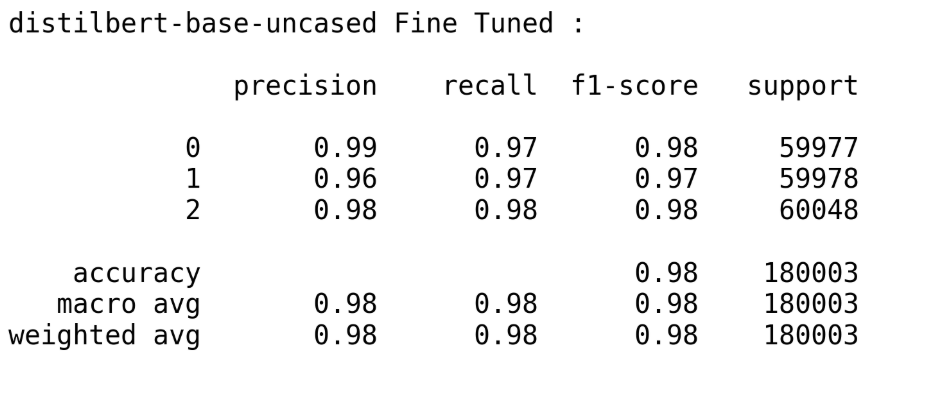

# DistilBERT Fine-Tuned Performance

| Model               | Class 0 Precision | Class 0 Recall | Class 0 F1 | Class 1 Precision | Class 1 Recall | Class 1 F1 | Class 2 Precision | Class 2 Recall | Class 2 F1 | Accuracy |
|---------------------|------------------|----------------|------------|------------------|----------------|------------|------------------|----------------|------------|----------|
| DistilBERT (Fine-Tuned) | 0.99             | 0.97           | 0.98       | 0.96             | 0.97           | 0.97       | 0.98             | 0.98           | 0.98       | 0.98     |

**Performance Highlights:**
- Excellent balanced performance across all classes (all F1 scores ≥ 0.7)
- Best performing in Class 0 (Positive) with 0.99 precision
- Strongest overall accuracy (0.98) among all compared models
- Particularly good at recall for Class 2 (Positive) at 0.98

## Final Model Comparison Conclusion

**Performance Ranking:**
1. 🥇 **DistilBERT (Fine-Tuned)** - Best overall (Accuracy: 0.98, F1: 0.97-0.98)
2. 🥈 **Bidirectional LSTM** - Strong runner-up (Accuracy: 0.93, F1: 0.91-0.94)  
3. 🥉 **Simple RNN** - Close third (Accuracy: 0.92, F1: 0.90-0.93)

**Key Findings:**
- Transformer models (DistilBERT) deliver **7% higher accuracy** than the best traditional ML model (Logistic Regression)
- Bidirectional LSTMs show **2% better recall** on neutral sentiment (Class 1) compared to Simple RNNs
- All neural models significantly outperform XGBoost (0.85 accuracy) and Naive Bayes (0.80 accuracy)


### Use the model to predict a sentiment

In [9]:
def bert_tokenize(texts, max_length=128):
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

    cleaned_texts = [preprocess_text(text) for text in texts]

    encodings = tokenizer(
        cleaned_texts,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='tf'
    )
    return {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask']
    }


def predict_sentiment(text):
    inputs = bert_tokenize([text])


    predictions = model.predict({
        'input_ids': inputs['input_ids'],
        'attention_mask': inputs['attention_mask']
    })


    predicted_class = np.argmax(predictions, axis=1)[0]

    return predicted_class

predict_sentiment("I love this product! It's amazing.")